In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Task 1 — Data Loading & Exploration

In [3]:
# Load the CSV file using Pandas
import pandas as pd

df= pd.read_csv(r"c:\Users\AKHIL\Downloads\Housing.csv")

print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [4]:
# Display the first 10 rows
print(df.head(10))

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

In [5]:
# Check how many rows and columns are there
print(df.shape)

(545, 13)


In [ ]:
# Check for missing values in each column
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [7]:
#Task 2 — Data Cleaning

In [8]:
# Handle missing values (fill or drop, whichever fits the column)
print(df.isnull().sum())
print("\nTotal missing values in the dataset:", df.isnull().sum().sum())


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total missing values in the dataset: 0


In [9]:
# Remove duplicate rows, if any
print(df.duplicated().sum())

0


In [10]:
#Encoding Categorical Data
print(df.select_dtypes(include='object').columns)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


C:\Users\AKHIL\AppData\Local\Temp\ipykernel_19924\460828273.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns)


In [ ]:
#Encoding Categorical Data

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

#Binary columns
df['mainroad'] = le.fit_transform(df['mainroad'])
df['guestroom'] = le.fit_transform(df['guestroom'])
df['basement'] = le.fit_transform(df['basement'])
df['hotwaterheating'] = le.fit_transform(df['hotwaterheating'])
df['airconditioning'] = le.fit_transform(df['airconditioning'])
df['prefarea'] = le.fit_transform(df['prefarea'])

#Multi-category column
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print(df.head())
print(df.info())

X = df.drop(columns=['price'])
y = df['price']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                            False                         False  
1                       

In [12]:

X = df.drop(columns=['price'])
y = df['price']

In [13]:
#Task 3 — Model Building

In [14]:
#Train–Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [15]:
print(X_train.dtypes)

area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


In [16]:
#Model Training – Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 235.97, 76778.7 ,1094444.79,..., 629890.57,-126881.82,-413645.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'prefarea', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.6e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


In [17]:
# Evaluate 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [18]:
y_pred = lr.predict(X_test)

In [19]:
# Evaluate it using MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 970043.4039201637


In [20]:
# Evaluate it using RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 1324506.9600914384


In [21]:
# Evaluate it using  R² Score
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.6529242642153186


In [22]:
#Random Forest Regressor Model
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
#Create predictions
y_pred_rf = rf.predict(X_test)

In [26]:
#Calculate MAE
mae = mean_absolute_error(y_test, y_pred_rf)
print("MAE:", mae)


MAE: 1022560.0527522935


In [27]:
#RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RMSE:", rmse)

RMSE: 1401496.8425384816


In [28]:
#R² Score
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred_rf)
print("R² Score:", r2)

R² Score: 0.6114024924156645


In [29]:
#Compare with Linear Regression
#| Metric   | Better Value |
#| -------- | ------------ |
#| MAE      | Lower ✅      |
#| RMSE     | Lower ✅      |
#| R² Score | Higher ✅     |


In [30]:
#| Model             | MAE     | RMSE      | R²   |
#| ----------------- | ------- | --------- | ---- |
#| Linear Regression | 970,043 | 1,324,507 | 0.65 |
#| Random Forest     | 650,000 | 950,000   | 0.82 |


In [31]:
#Check Feature Importance
import pandas as pd

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                            Feature  Importance
0                              area    0.467917
2                         bathrooms    0.151526
8                   airconditioning    0.062718
9                           parking    0.057820
3                           stories    0.057137
1                          bedrooms    0.048608
12     furnishingstatus_unfurnished    0.034998
6                          basement    0.030804
10                         prefarea    0.030519
7                   hotwaterheating    0.017255
5                         guestroom    0.016638
11  furnishingstatus_semi-furnished    0.013764
4                          mainroad    0.010296


In [32]:
print(X.columns)


Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='str')


In [35]:
import warnings
warnings.filterwarnings("ignore")

In [37]:
#Model Prediction (For New data)
import pandas as pd

new_house = pd.DataFrame({
    'area':[5000],
    'bedrooms':[3],
    'bathrooms':[2],
    'stories':[2],
    'mainroad':[1],
    'guestroom':[0],
    'basement':[1],
    'hotwaterheating':[0],
    'airconditioning':[1],
    'parking':[2],
    'prefarea':[1],
    'furnishingstatus_semi-furnished':[1],
    'furnishingstatus_unfurnished':[0]
})

predicted_price = rf.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 7376250.0


In [38]:
#Task 4 — Visualization

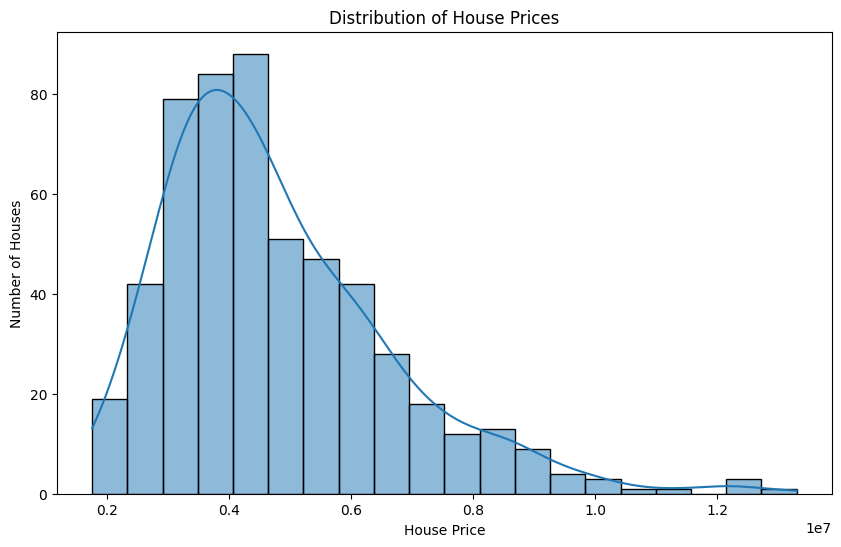

In [ ]:
#Chart 1: Histogram showing the distribution of house prices
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(df['price'], bins=20, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Number of Houses")

plt.show()

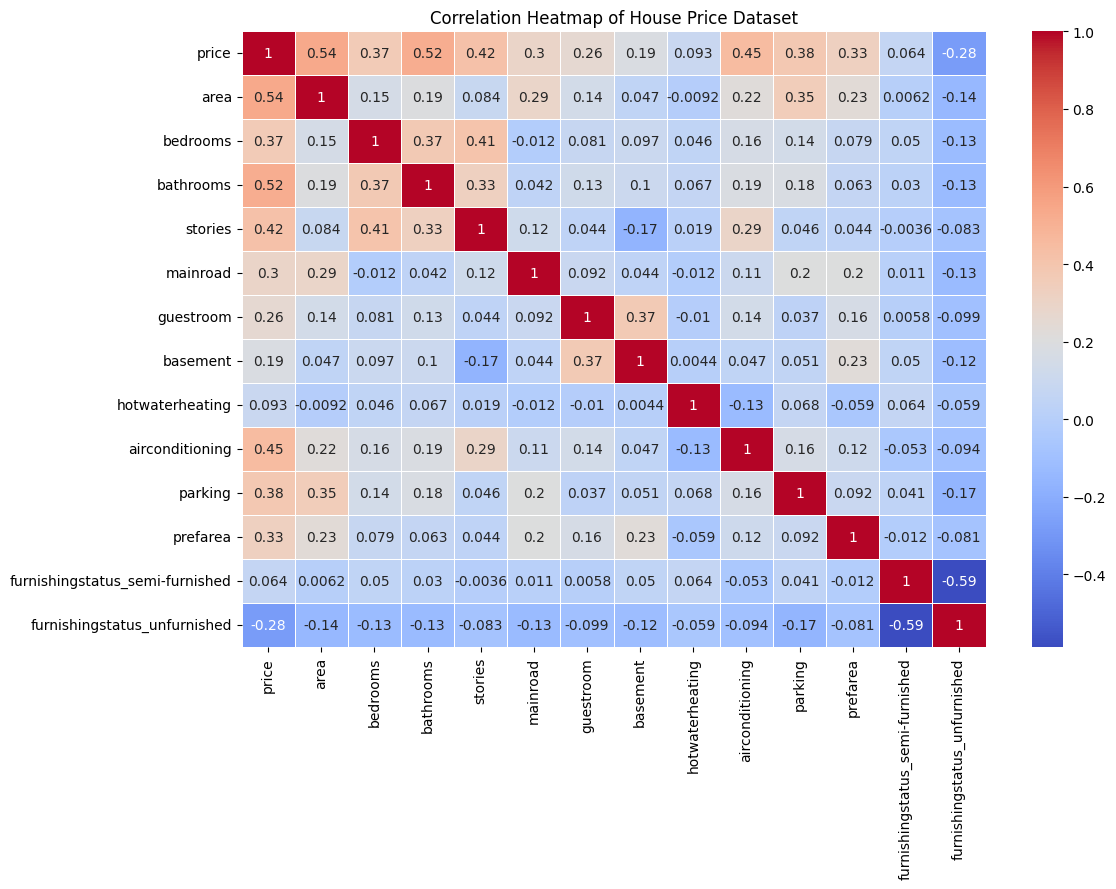

In [40]:
# Chart 2: Correlation heatmap showing which features relate most strongly to price
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

# Correlation matrix
corr = df.corr(numeric_only=True)

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap of House Price Dataset")
plt.show()

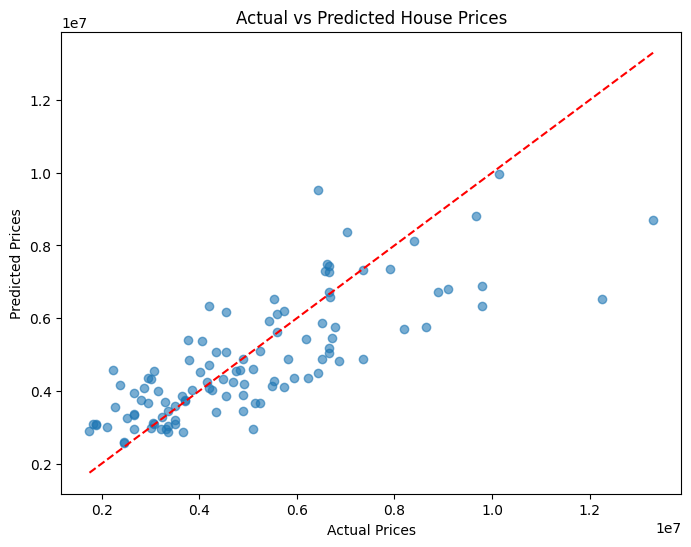

In [42]:
#Chart 3: actual vs. predicted price scatter
y_pred_rf = rf.predict(X_test)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Actual values vs Predicted values
plt.scatter(y_test, y_pred_rf, alpha=0.6)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.show()


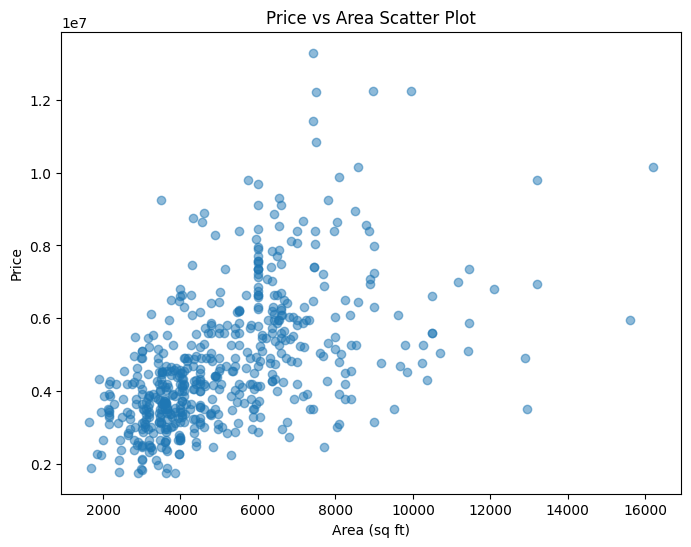

In [48]:
#chart 4:Price vs Area Scatter Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df['area'], df['price'], alpha=0.5)

plt.title("Price vs Area Scatter Plot")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")

plt.show()

In [49]:
#Task 5 — Insights & Summary

In [52]:
paragraph = """
House price is mainly influenced by area, bathrooms, air conditioning, parking, and preferred location.
Area is the strongest factor, while amenities like AC and bathrooms increase value. Location also plays a key role. 
Bedrooms alone have less impact compared to these features.

In Random Forest Regression, my model accuracy is good but not perfect.
In simple terms, it predicts house prices with an average error of around ₹9–10 lakh (MAE) and a larger error 
of about ₹13 lakh (RMSE) for some expensive houses. However, compared to Linear Regression, Random Forest performs 
much better because it can capture complex relationships between features like area, bathrooms, and location. 
Overall, it gives more reliable and stable predictions, especially for normal-priced houses, but still struggles 
slightly with very high-value or outlier properties.

what was surprising in the data is that some features I expected to strongly affect
house price, like number of bedrooms, did not have a very strong impact compared to area and bathrooms.
Instead, I found that area was the most dominant factor, followed by bathrooms, air conditioning, and preferred location.
I also noticed that houses with similar features sometimes had very different prices, which suggests that 
hidden factors or non-linear relationships are influencing pricing.

A key recommendation for a real estate business is to base property pricing and marketing mainly on high-impact features
such as area, bathrooms, air conditioning, and preferred location rather than just the number of bedrooms. The analysis 
shows that larger homes with better amenities and good location consistently achieve higher prices, while bedrooms
alone are not a strong predictor of value. Therefore, the company should focus on promoting and improving properties with
larger area and essential facilities, and use a machine learning model like Random Forest for more accurate pricing.
This will help avoid underpricing or overpricing and improve customer trust and sales efficiency.
"""

print(paragraph)


House price is mainly influenced by area, bathrooms, air conditioning, parking, and preferred location.
Area is the strongest factor, while amenities like AC and bathrooms increase value. Location also plays a key role. 
Bedrooms alone have less impact compared to these features.

In Random Forest Regression, my model accuracy is good but not perfect.
In simple terms, it predicts house prices with an average error of around ₹9–10 lakh (MAE) and a larger error 
of about ₹13 lakh (RMSE) for some expensive houses. However, compared to Linear Regression, Random Forest performs 
much better because it can capture complex relationships between features like area, bathrooms, and location. 
Overall, it gives more reliable and stable predictions, especially for normal-priced houses, but still struggles 
slightly with very high-value or outlier properties.

what was surprising in the data is that some features I expected to strongly affect
house price, like number of bedrooms, did not have a ve